# Reinforcement Learning Individual Assignment
## Text Flappy Bird - GLIE Monte-Carlo Control Agent

In [1]:
import os, sys
import gymnasium as gym
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import pickle
from pathlib import Path

import text_flappy_bird_gym

## 1. Environment Setup

We use the simple state variant `TextFlappyBird-v0` which returns `(x_distance, y_distance)` — the horizontal and vertical distance from the bird to the centre of the nearest pipe gap. The action space is `Discrete(2)`: **0 = idle** (do nothing), **1 = flap**.

In [2]:
# Initialise the environment (simple state: x_dist, y_dist)
env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)

obs, info = env.reset()
print(f"Observation: {obs}")
print(f"Action space: {env.action_space}")  # Discrete(2)

Observation: (13, -2)
Action space: Discrete(2)


## 2. GLIE Monte-Carlo Control Agent

The agent maintains:
- **Q(s, a)**: action-value estimates (dictionary keyed by `(state, action)`)
- **N(s, a)**: visit counts for each state-action pair
- **$\epsilon$**: exploration rate, decayed as $\epsilon = 1/k$ (episode number) to satisfy the GLIE condition

The $\epsilon$-greedy policy selects:
- the greedy action with probability $1 - \epsilon + \epsilon/m$
- each non-greedy action with probability $\epsilon/m$

where $m$ is the number of actions.

In [3]:
class GLIEMCAgent:
    """GLIE Monte-Carlo Control agent for Text Flappy Bird."""

    def __init__(self, n_actions: int = 2, min_epsilon: float = 0.01, max_epsilon: float = 1.0, decay_step: float = 0.0001, lambda_: float = 0.0001):
        self.n_actions = n_actions
        self.min_epsilon = min_epsilon
        self.max_epsilon = max_epsilon
        self.decay_step = decay_step    # for linear decay
        self.lambda_ = lambda_          # for exponential decay
        # Q-values and visit counts stored as dicts for sparse state space
        self.Q = defaultdict(float)         # (state, action) -> value
        self.N = defaultdict(int)           # (state, action) -> visit count
        self.epsilon = 1.0
        self.episode_count = 0

    # policy
    def get_action(self, state: tuple) -> int:
        """Select an action using the epsilon-greedy policy w.r.t. current Q."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        # greedy: pick action with highest Q (break ties randomly)
        q_values = [self.Q[(state, a)] for a in range(self.n_actions)]
        max_q = max(q_values)
        best_actions = [a for a, q in enumerate(q_values) if q == max_q]
        return np.random.choice(best_actions)

    def greedy_action(self, state: tuple) -> int:
        """Purely greedy action (for evaluation)."""
        q_values = [self.Q[(state, a)] for a in range(self.n_actions)]
        max_q = max(q_values)
        best_actions = [a for a, q in enumerate(q_values) if q == max_q]
        return np.random.choice(best_actions)

    # learning
    def update(self, episode: list[tuple], gamma: float = 1.0):
        """
        Update Q from a complete episode using first-visit MC.

        Parameters
        ----------
        episode : list of (state, action, reward) tuples
        gamma   : discount factor (1.0 for undiscounted)
        """
        G = 0.0
        visited = set()
        # Walk backwards through the episode
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = gamma * G + reward

            sa = (state, action)
            # First-visit: only update the first time we see (s, a)
            if sa not in visited:
                visited.add(sa)
                self.N[sa] += 1
                # Incremental mean update: Q ← Q + (1/N)(G - Q)
                self.Q[sa] += (1.0 / self.N[sa]) * (G - self.Q[sa])

    def decay_epsilon(self, n_episodes: int, decay_type: str = "linear"):
        """GLIE epsilon decay: linear decay over all training episodes."""
        self.episode_count += 1
        if decay_type == "inverse":
            self.epsilon = max(self.min_epsilon, 1.0 / self.episode_count)
        elif decay_type == "linear":
            self.epsilon = max(self.min_epsilon, self.max_epsilon - self.episode_count * self.decay_step)
        elif decay_type == "exponential":
            self.epsilon = self.min_epsilon + (self.max_epsilon - self.min_epsilon) * np.exp(- self.lambda_ * self.episode_count)

## 3. Training Loop

We run thousands of episodes. In each episode we:
1. Generate a full trajectory under the current $\epsilon$-greedy policy.
2. Compute returns and update $Q(s,a)$ (first-visit MC).
3. Decay $\epsilon \leftarrow 1/k$.

In [4]:
def train(env, agent, n_episodes: int = 50_000, gamma: float = 1.0, log_every: int = 1000, decay_type: str = "linear"):
    """Train the GLIE MC agent and return training statistics."""
    reward_history = []     # total reward per episode
    avg_rewards = []        # running average (over last `log_every` episodes)
    epsilon_history = []
    print(f"Starting training with {n_episodes} episodes, gamma={gamma}, decay_type={decay_type}")
    for k in tqdm(range(1, n_episodes + 1), desc="Training"):
        # Generate an episode
        obs, _ = env.reset()
        state = tuple(obs)
        episode = []
        total_reward = 0.0

        done = False
        while not done:
            action = agent.get_action(state)
            next_obs, reward, done, _, info = env.step(action)
            episode.append((state, action, reward))
            total_reward += reward
            state = tuple(next_obs)

        # Update Q-values
        agent.update(episode, gamma=gamma)

        # Decay epsilon (GLIE)
        agent.decay_epsilon(n_episodes, decay_type=decay_type)

        # Logging
        reward_history.append(total_reward)
        epsilon_history.append(agent.epsilon)

        if k % log_every == 0:
            avg_r = np.mean(reward_history[-log_every:])
            avg_rewards.append(avg_r)
            print(f"Episode {k:>7d} | Avg reward (last {log_every}): {avg_r:7.2f} "
                  f"| \u03B5: {agent.epsilon:.5f} | Q-table size: {len(agent.Q)}")

    return reward_history, avg_rewards, epsilon_history

In [5]:
# Hyperparameters
N_EPISODES = 50_000
GAMMA = 0.99
MIN_EPSILON = 0.01
MAX_EPSILON = 1.0
DECAY_STEP = 0.001     # for linear decay
LAMBDA = 0.001         # for exponential decay
DECAY_TYPE = "exponential"  # "linear", "inverse", or "exponential"

# Create agent
env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
agent = GLIEMCAgent(n_actions=env.action_space.n, min_epsilon=MIN_EPSILON, max_epsilon=MAX_EPSILON, decay_step=DECAY_STEP, lambda_=LAMBDA)

TRAIN_AGENT = True
SAVE_AGENT = True

In [6]:
results_dir = Path.cwd().parent / 'results' / 'MC'
results_dir.mkdir(parents=True, exist_ok=True)
save_path = results_dir / 'mc_agent.pkl'

# Train or load agent
if TRAIN_AGENT:
    reward_history, avg_rewards, epsilon_history = train(env, agent, n_episodes=N_EPISODES, gamma=GAMMA, decay_type=DECAY_TYPE)

    # Save the trained Q-table
    if SAVE_AGENT:
        with open(save_path, 'wb') as f:
            pickle.dump({'Q': dict(agent.Q), 'N': dict(agent.N),
                         'epsilon': agent.epsilon, 'episode_count': agent.episode_count}, f)
        print(f"Agent saved to {save_path}")
else:
    if save_path.exists():
        with open(save_path, 'rb') as f:
            data = pickle.load(f)
        agent.Q = defaultdict(float, data['Q'])
        agent.N = defaultdict(int, data['N'])
        agent.epsilon = data['epsilon']
        agent.episode_count = data['episode_count']
        print(f"Agent loaded from {save_path}")
    else:
        print(f"No saved agent found at {save_path}. Please train the agent first.")

Starting training with 50000 episodes, gamma=0.99, decay_type=exponential


Training:   3%|▎         | 1317/50000 [00:01<00:55, 884.13it/s] 

Episode    1000 | Avg reward (last 1000):   19.94 | ε: 0.37420 | Q-table size: 535


Training:   4%|▍         | 2020/50000 [00:02<01:52, 425.82it/s]

Episode    2000 | Avg reward (last 1000):   49.19 | ε: 0.14398 | Q-table size: 545


...

Episode   48000 | Avg reward (last 1000):  336.75 | ε: 0.01000 | Q-table size: 545


Training:  98%|█████████▊| 49012/50000 [08:18<00:10, 93.21it/s] 

Episode   49000 | Avg reward (last 1000):  383.44 | ε: 0.01000 | Q-table size: 545


Training: 100%|██████████| 50000/50000 [08:29<00:00, 98.21it/s] 

Episode   50000 | Avg reward (last 1000):  304.79 | ε: 0.01000 | Q-table size: 545
Agent saved to c:\Users\adoni\Desktop\Reinforcement Learning\MDS-RL\individual assignment\results\MC\mc_agent.pkl


## 4. Training Curves

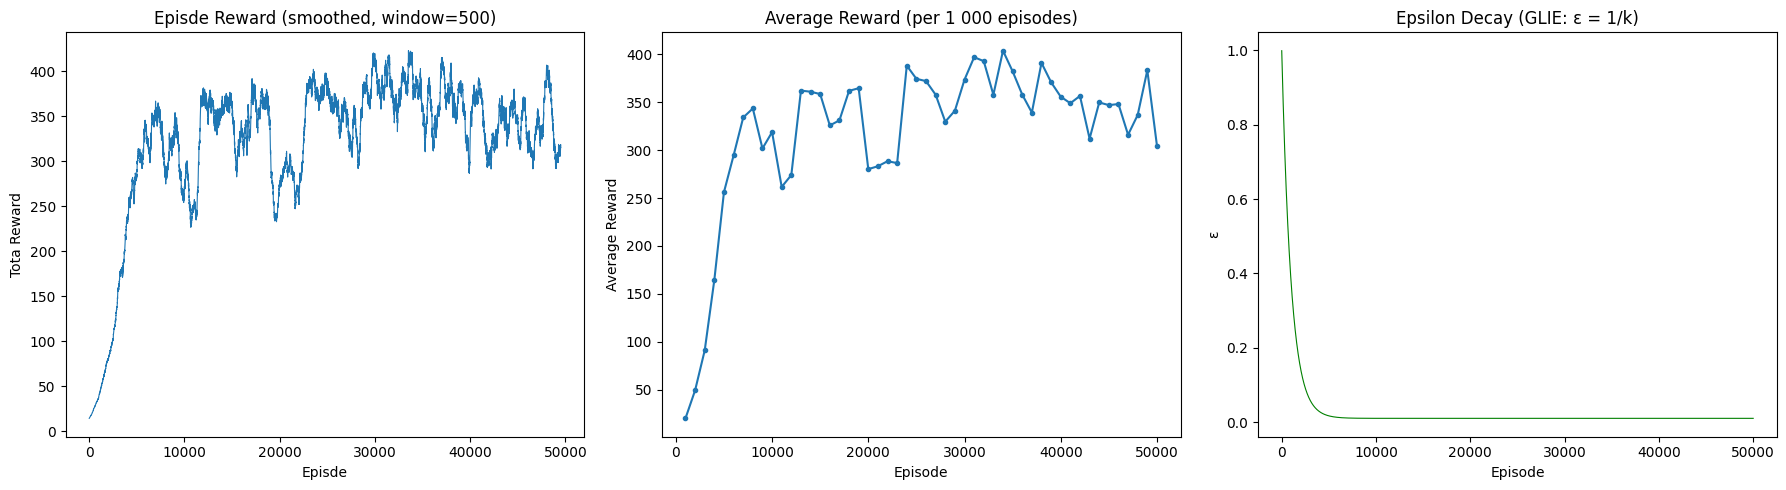

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Episode reward (smoothed)
window = 500
smoothed = np.convolve(reward_history, np.ones(window)/window, mode='valid')
axes[0].plot(smoothed, linewidth=0.8)
axes[0].set_xlabel('Episde')
axes[0].set_ylabel('Tota Reward')
axes[0].set_title(f'Episde Reward (smoothed, window={window})')
# Average reward per loging interval
axes[1].plot(range(1000, N_EPISODES + 1, 1000), avg_rewards, marker='o', markersize=3)
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Average Reward')
axes[1].set_title('Average Reward (per 1 000 episodes)')

# Epsilon decay
axes[2].plot(epsilon_history, linewidth=0.8, color='green')
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('\u03B5')
axes[2].set_title('Epsilon Decay (GLIE: \u03B5 = 1/k)')

plt.tight_layout()
plt.show()

## 5. Evaluation (Greedy Policy)

Run the fully trained agent (greedy, $\epsilon = 0$) for several episodes to measure its average performance.

Evaluating: 100%|██████████| 1000/1000 [00:51<00:00, 19.53it/s]


Greedy evaluation over 1 000 episodes:
  Mean reward : 1819.21
  Std reward  : 1838.26
  Max reward  : 12870
  Min reward  : 20


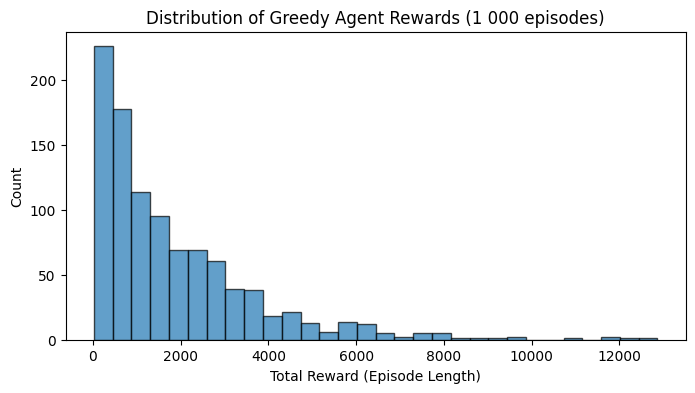

In [8]:
def evaluate(env, agent, n_episodes: int = 1000):
    """Evaluate the agent using a purely greedy policy (no exploration)."""
    total_rewards = []
    for _ in tqdm(range(n_episodes), desc="Evaluating"):
        obs, _ = env.reset()
        state = tuple(obs)
        total_reward = 0.0
        done = False
        while not done:
            action = agent.greedy_action(state)
            obs, reward, done, _, info = env.step(action)
            state = tuple(obs)
            total_reward += reward
        total_rewards.append(total_reward)
    return total_rewards

eval_rewards = evaluate(env, agent, n_episodes=1000)
print(f"Greedy evaluation over 1 000 episodes:")
print(f"  Mean reward : {np.mean(eval_rewards):.2f}")
print(f"  Std reward  : {np.std(eval_rewards):.2f}")
print(f"  Max reward  : {np.max(eval_rewards):.0f}")
print(f"  Min reward  : {np.min(eval_rewards):.0f}")

plt.figure(figsize=(8, 4))
plt.hist(eval_rewards, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Total Reward (Episode Length)')
plt.ylabel('Count')
plt.title('Distribution of Greedy Agent Rewards (1 000 episodes)')
plt.show()

## 6. Hyperparameter Grid Search

We perform a grid search over decay types and their associated parameters to find the configuration that maximises mean greedy reward after a fixed training budget.

Each configuration is trained for **15 000 episodes** (a reduced budget for tractability) and evaluated greedily over **200 episodes**. To reduce noise, each configuration is run **3 times** and results are averaged.

| Decay type | Parameter swept |
|---|---|
| `inverse`     | — (no free parameter) |
| `linear`      | `decay_step` |
| `exponential` | `lambda_` |

`min_epsilon` is also swept across all types.

In [11]:
# Grid definition
GS_EPISODES   = 10_000          # training budget per config
GS_EVAL_EPS   = 200             # greedy evaluation episodes per run
GS_N_SEEDS    = 1               # independent runs per config (for averaging)
GS_GAMMA      = 0.99
GS_LOG_EVERY  = GS_EPISODES + 1 # suppress per-episode logging

min_epsilons   = [0.01, 0.05, 0.10]
decay_steps    = [0.0001, 0.001, 0.005]     # linear
lambdas        = [0.0001, 0.0005, 0.001]   # exponential

# Build list of (label, decay_type, agent_kwargs)
grid = []

for me in min_epsilons:
    grid.append((f"inverse | min_ε={me}", "inverse",
                 dict(min_epsilon=me)))

for me in min_epsilons:
    for ds in decay_steps:
        grid.append((f"linear | step={ds} | min_ε={me}", "linear",
                     dict(min_epsilon=me, decay_step=ds)))

for me in min_epsilons:
    for lm in lambdas:
        grid.append((f"exponential | λ={lm} | min_ε={me}", "exponential",
                     dict(min_epsilon=me, lambda_=lm)))

print(f"Total configurations: {len(grid)}")
print(f"Total training runs : {len(grid) * GS_N_SEEDS}  "
      f"({len(grid) * GS_N_SEEDS * GS_EPISODES:,} episodes in total)")

Total configurations: 21
Total training runs : 21  (210,000 episodes in total)


In [12]:
# Grid search
gs_env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)

gs_results = []  # list of dicts: label, decay_type, kwargs, mean_reward, std_reward

for label, decay_type, kwargs in tqdm(grid, desc="Grid configs"):
    run_means = []
    for seed in range(GS_N_SEEDS):
        np.random.seed(seed)
        gs_agent = GLIEMCAgent(n_actions=gs_env.action_space.n, **kwargs)
        train(gs_env, gs_agent, n_episodes=GS_EPISODES, gamma=GS_GAMMA,
              log_every=GS_LOG_EVERY, decay_type=decay_type)
        run_rewards = evaluate(gs_env, gs_agent, n_episodes=GS_EVAL_EPS)
        run_means.append(np.mean(run_rewards))

    gs_results.append({
        "label":       label,
        "decay_type":  decay_type,
        "kwargs":      kwargs,
        "mean_reward": np.mean(run_means),
        "std_reward":  np.std(run_means),
    })

gs_results.sort(key=lambda r: r["mean_reward"], reverse=True)
print("\nTop 10 configurations:")
print(f"{'Rank':<5} {'Mean Reward':>12} {'Std':>8}  Label")
print("-" * 75)
for i, r in enumerate(gs_results[:10], 1):
    print(f"{i:<5} {r['mean_reward']:>12.2f} {r['std_reward']:>8.2f}  {r['label']}")

Grid configs:   0%|          | 0/21 [00:00<?, ?it/s]

Starting training with 10000 episodes, gamma=0.99, decay_type=inverse


Grid configs:   5%|▍         | 1/21 [01:07<22:23, 67.19s/it]

Starting training with 10000 episodes, gamma=0.99, decay_type=inverse


Grid configs:  10%|▉         | 2/21 [01:37<14:26, 45.62s/it]

Starting training with 10000 episodes, gamma=0.99, decay_type=inverse


Grid configs:  14%|█▍        | 3/21 [02:10<11:57, 39.88s/it]

Starting training with 10000 episodes, gamma=0.99, decay_type=linear


Grid configs:  14%|█▍        | 3/21 [1:08:07<6:48:42, 1362.39s/it]


KeyboardInterrupt: 

In [ ]:
# Visualise results
df = pd.DataFrame(gs_results)

# Top 15 configs
top_n = min(15, len(df))
df_top = df.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors = {"inverse": "#4C72B0", "linear": "#DD8452", "exponential": "#55A868"}
bar_colors = [colors[dt] for dt in df_top["decay_type"]]

axes[0].barh(df_top["label"][::-1], df_top["mean_reward"][::-1],
             xerr=df_top["std_reward"][::-1], color=bar_colors[::-1],
             capsize=4, edgecolor="black", linewidth=0.5)
axes[0].set_xlabel("Mean Greedy Reward")
axes[0].set_title(f"Top {top_n} Configurations (grid search)")
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in colors.items()]
axes[0].legend(handles=legend_elements, title="Decay type", loc="lower right")

# Mean reward by decay type
decay_groups = {dt: df[df["decay_type"] == dt]["mean_reward"].values
                for dt in ["inverse", "linear", "exponential"]}
axes[1].boxplot(decay_groups.values(), labels=decay_groups.keys(), patch_artist=True,
                boxprops=dict(facecolor="lightblue"),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_ylabel("Mean Greedy Reward")
axes[1].set_title("Reward Distribution by Decay Type")

plt.tight_layout()
plt.savefig(Path.cwd().parent / "results" / "MC" / "gridsearch_results.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Best config
best = gs_results[0]
print("\nBest configuration found:")
print(f"  Decay type : {best['decay_type']}")
print(f"  Parameters : {best['kwargs']}")
print(f"  Mean reward: {best['mean_reward']:.2f} ± {best['std_reward']:.2f}")

## 7. Live Demo

Run the trained agent with the screen variant and watch it play in real-time using the scripts/MCAgent.py script.